# CS6444 Project 1 - R and Graph Analytics
## Stanford Web Graph (2002)

### Team
- Fatulla Bashirov
- Kamal Ahmadov

### Dataset and context
The Stanford Web Graph models webpages as vertices and hyperlinks as directed edges. It is a large real-world graph suitable for centrality, connectivity, clique, ego-network, and community analysis.

### Business/social problem
This graph supports a web discovery problem: identifying authoritative pages, navigation bottlenecks, and community structure in a large hyperlink network so that search, navigation, and information organization can be understood more effectively.

### Why this dataset
- Satisfies the assignment scale requirement (well above 50,000 vertices).
- Represents a realistic information network with directional relationships.
- Supports graph simplification experiments and interpretable subgraph visualization.

### Team task split
- Fatulla Bashirov: dataset loading, graph construction, simplification pipeline, and reproducibility setup.
- Kamal Ahmadov: additional `igraph` experimentation, interpretation write-up, visualization presentation, and final notebook review.


## Notebook roadmap
We kept the notebook close to the order we followed while working on the assignment:
- load the raw edge list and verify the scale of the network;
- build the initial directed graph and record its basic properties;
- simplify the graph into a smaller version that we can analyze and visualize;
- try extra `igraph` functions beyond the tutorial examples;
- answer the required analysis questions and finish with two readable figures.


## 0. Setup
I load the packages first, set the main parameters once, and keep the helper functions here so the later analysis cells stay shorter.


In [ ]:
# ---- package setup ----
required_packages <- c("igraph", "data.table")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(igraph)
  library(data.table)
})


In [ ]:
# ---- runtime configuration ----
cfg <- list(
  seed = 6444,
  analysis_node_cap = 50000,
  task_node_cap = 450,
  triad_sample_size = 120,
  viz_node_cap = 80,
  baseline_sample_size = 10000,
  power_exponents = c(0.25, 0.10, 0.05, 0.01)
)

set.seed(cfg$seed)
options(width = 120)


In [ ]:
# ---- small helpers ----
resolve_dataset_path <- function(candidate_paths) {
  existing <- candidate_paths[file.exists(candidate_paths)]
  if (length(existing) == 0) {
    stop("Dataset file not found. Place web-Stanford.txt in ./data or provide a valid Kaggle path.")
  }
  existing[[1]]
}

safe_power_centrality <- function(graph_obj, exponents) {
  for (ex in exponents) {
    candidate <- tryCatch(
      power_centrality(graph_obj, exponent = ex),
      error = function(e) NULL
    )
    if (!is.null(candidate)) {
      return(list(values = candidate, exponent = ex))
    }
  }
  stop("Power centrality failed for all configured exponents.")
}


In [ ]:
# ---- build the retained analysis graph and smaller task graph ----
build_analysis_graph <- function(g, cfg) {
  g_simple <- simplify(g, remove.multiple = TRUE, remove.loops = TRUE)

  comp_simple <- components(as.undirected(g_simple, mode = "collapse"))
  giant_id <- which.max(comp_simple$csize)
  g_giant <- induced_subgraph(g_simple, V(g_simple)[comp_simple$membership == giant_id])

  giant_deg <- degree(g_giant, mode = "all")
  ranked_vertices <- names(sort(giant_deg, decreasing = TRUE))
  analysis_n <- min(cfg$analysis_node_cap, length(ranked_vertices))
  analysis_vertices <- ranked_vertices[1:analysis_n]
  g_analysis <- induced_subgraph(g_giant, vids = analysis_vertices)

  out_deg_a <- degree(g_analysis, mode = "out")
  in_deg_a <- degree(g_analysis, mode = "in")
  ee <- ends(g_analysis, E(g_analysis), names = TRUE)
  E(g_analysis)$weight <- as.numeric(log1p(out_deg_a[ee[, 1]]) + log1p(in_deg_a[ee[, 2]]))

  g_analysis_u <- as.undirected(
    g_analysis,
    mode = "collapse",
    edge.attr.comb = list(weight = "mean", "ignore")
  )

  pr_analysis <- page_rank(g_analysis, directed = TRUE)$vector
  task_n <- min(cfg$task_node_cap, length(pr_analysis))
  task_vertices <- names(sort(pr_analysis, decreasing = TRUE))[1:task_n]
  g_task <- induced_subgraph(g_analysis, vids = task_vertices)
  g_task_u <- as.undirected(
    g_task,
    mode = "collapse",
    edge.attr.comb = list(weight = "mean", "ignore")
  )

  stage_names <- c("original", "simplified", "largest_wcc", "analysis_graph", "task_graph")
  nodes <- c(vcount(g), vcount(g_simple), vcount(g_giant), vcount(g_analysis), vcount(g_task))
  edges <- c(ecount(g), ecount(g_simple), ecount(g_giant), ecount(g_analysis), ecount(g_task))

  summary_tbl <- data.frame(
    stage = stage_names,
    nodes = nodes,
    edges = edges,
    node_retention_vs_original = round(nodes / nodes[1], 6),
    edge_retention_vs_original = round(edges / edges[1], 6)
  )

  list(
    g_analysis = g_analysis,
    g_analysis_u = g_analysis_u,
    g_task = g_task,
    g_task_u = g_task_u,
    summary_tbl = summary_tbl
  )
}


In [ ]:
# ---- build a readable visualization subgraph ----
make_viz_subgraph <- function(g_analysis, central_table, cfg) {
  viz_n <- min(cfg$viz_node_cap, nrow(central_table))
  viz_nodes <- central_table$vertex[1:viz_n]

  g_viz <- induced_subgraph(g_analysis, vids = V(g_analysis)[viz_nodes])
  g_viz_u <- as.undirected(
    g_viz,
    mode = "collapse",
    edge.attr.comb = list(weight = "mean", "ignore")
  )

  viz_comm <- cluster_walktrap(g_viz_u, weights = E(g_viz_u)$weight)
  member <- membership(viz_comm)

  palette_vals <- hcl.colors(length(unique(member)), palette = "Dark 3")
  V(g_viz_u)$color <- palette_vals[member]

  pr_viz <- page_rank(g_viz, directed = TRUE)$vector
  pr_scaled <- 6 + 18 * (pr_viz - min(pr_viz)) / (max(pr_viz) - min(pr_viz) + 1e-9)
  V(g_viz_u)$size <- pr_scaled[V(g_viz_u)$name]

  top10_viz <- names(sort(pr_viz, decreasing = TRUE))[1:min(10, length(pr_viz))]
  V(g_viz_u)$shape <- ifelse(V(g_viz_u)$name %in% top10_viz, "square", "circle")
  V(g_viz_u)$label <- NA
  V(g_viz_u)$frame.color <- "gray20"

  w <- E(g_viz_u)$weight
  w_scaled <- 1 + 3 * (w - min(w)) / (max(w) - min(w) + 1e-9)
  E(g_viz_u)$width <- w_scaled
  E(g_viz_u)$color <- ifelse(w >= median(w), "firebrick", "gray70")

  e_ends <- ends(g_viz_u, E(g_viz_u), names = FALSE)
  E(g_viz_u)$lty <- ifelse(member[e_ends[, 1]] == member[e_ends[, 2]], 1, 2)

  list(graph = g_viz_u, community = viz_comm)
}


## 1. Load data and inspect the raw edge list
I start by resolving the dataset path, loading the edge list, and taking a quick look at the rows and summary statistics before building the graph.


In [ ]:
candidate_paths <- c(
  "./data/web-Stanford.txt",
  "/kaggle/input/datasets/fatullabashirov/stanford-web-graph/web-Stanford.txt"
)

file_path <- resolve_dataset_path(candidate_paths)

file_header <- readLines(file_path, n = 200L, warn = FALSE)
first_data_line <- which(nzchar(trimws(file_header)) & !grepl("^\\s*#", file_header))[1]
if (is.na(first_data_line)) {
  stop("Could not find the first data row in the edge-list file.")
}

edges <- fread(
  file_path,
  sep = "	",
  header = FALSE,
  skip = first_data_line - 1L,
  col.names = c("from", "to")
)

cat("Using file:", file_path, "\n")
cat("Raw edge-list rows:", nrow(edges), "\n")
cat("Columns:", ncol(edges), "\n")


Using file: ./data/web-Stanford.txt 


Raw edge-list rows: 2312497 


Columns: 2 


In [ ]:
head(edges)


from,to
<int>,<int>
1,6548
1,15409
6548,57031
15409,13102
2,17794
2,25202


In [ ]:
summary(edges)


      from              to        
 Min.   :     1   Min.   :     2  
 1st Qu.: 70779   1st Qu.: 73100  
 Median :141051   Median :143725  
 Mean   :140961   Mean   :143950  
 3rd Qu.:211225   3rd Qu.:218070  
 Max.   :281903   Max.   :281903  

## 2. Build the initial graph and record the required properties
This section covers the assignment basics: node count, edge count, sparsity, direction, degree summaries, and connected-component structure.


In [ ]:
g <- graph_from_data_frame(edges, directed = TRUE)

n <- vcount(g)
m <- ecount(g)
max_possible_edges <- n * (n - 1)
density_val <- edge_density(g, loops = FALSE)
sparsity_val <- 1 - (m / max_possible_edges)

cat("Vertices:", n, "\n")
cat("Edges:", m, "\n")
cat("Directed (arrowness):", is_directed(g), "\n")
cat("Has loops:", any_loop(g), "\n")
cat("Density:", density_val, "\n")
cat("Sparsity:", sparsity_val, "\n")


Vertices: 281903 


Edges: 2312497 


Directed (arrowness): TRUE 


Has loops: FALSE 


Density: 2.909935e-05 


Sparsity: 0.9999709 


In [ ]:
in_deg_full <- degree(g, mode = "in")
out_deg_full <- degree(g, mode = "out")
total_deg_full <- degree(g, mode = "all")

cat("\nNode property summaries:\n")
cat("In-degree:\n")
print(summary(in_deg_full))
cat("\nOut-degree:\n")
print(summary(out_deg_full))
cat("\nTotal-degree:\n")
print(summary(total_deg_full))



Node property summaries:


In-degree:


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.000     1.000     2.000     8.203     4.000 38606.000 



Out-degree:


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   2.000   5.000   8.203   9.000 255.000 



Total-degree:


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    1.00     5.00     8.00    16.41    12.00 38626.00 


In [ ]:
wcc <- components(as.undirected(g, mode = "collapse"))
scc <- components(g, mode = "strong")

cat("\nEdge/structure property summaries:\n")
cat("Weakly connected components:", wcc$no, "\n")
cat("Largest WCC size:", max(wcc$csize), "\n")
cat("Strongly connected components:", scc$no, "\n")
cat("Largest SCC size:", max(scc$csize), "\n")
cat("Edge weights in raw data: none (assigned later as synthetic deterministic weights).\n")



Edge/structure property summaries:


Weakly connected components: 365 


Largest WCC size: 255265 


Strongly connected components: 29914 


Largest SCC size: 150532 


Edge weights in raw data: none (assigned later as synthetic deterministic weights).


### Figure 1. Baseline View Before Simplification
As expected, a direct plot of the large graph appears as a dense blob and is not interpretable. This baseline justifies simplification in Section 3.

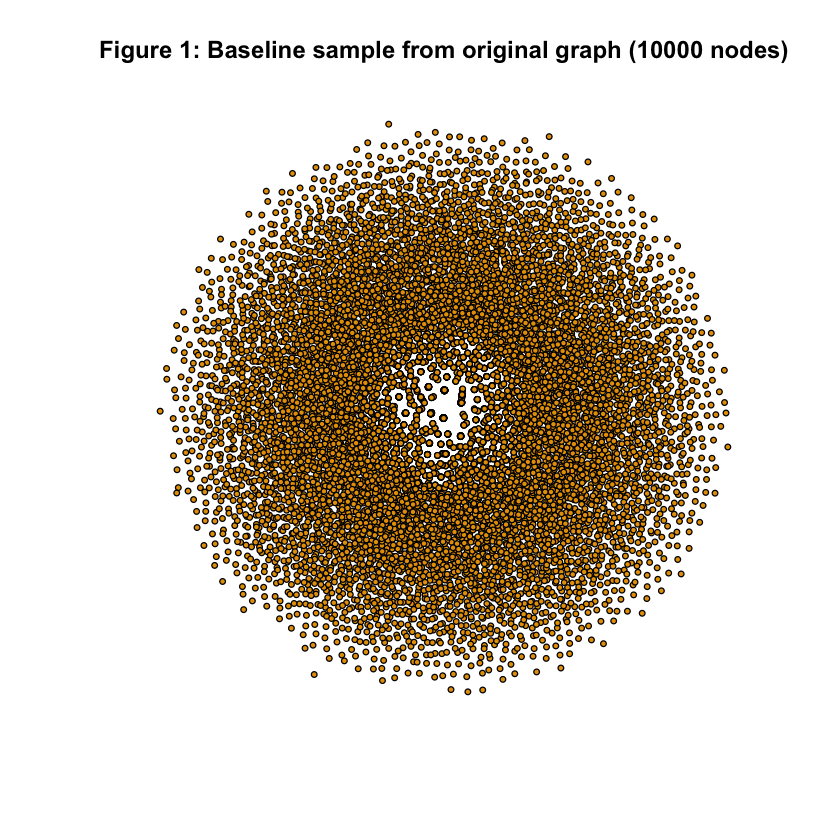

In [ ]:
sample_size <- min(cfg$baseline_sample_size, vcount(g))
sample_nodes <- sample(V(g), sample_size)
g_sample_original <- induced_subgraph(g, sample_nodes)

plot(
  g_sample_original,
  vertex.size = 2,
  vertex.label = NA,
  edge.arrow.size = 0.05,
  main = sprintf("Figure 1: Baseline sample from original graph (%d nodes)", vcount(g_sample_original))
)


**Interpretation for Figure 1:** Most structure is visually compressed, so direct plotting of the full-scale network is not useful for decision-making. The remaining analysis therefore uses a reproducible multi-step simplification strategy.

## 3. Simplifying the graph
The full network is too large to inspect directly, so we keep two working views of it:
1. `simplify()` removes loops and duplicate edges.
2. We keep the largest weakly connected component.
3. We retain the top 50,000 vertices by total degree as the main analysis graph.
4. From that retained graph, we extract a 450-node focused core for the heavier algorithms and plots.

This keeps the notebook tied to a much larger network while still making the expensive graph analytics runnable.


In [ ]:
analysis_bundle <- build_analysis_graph(g, cfg)

g_analysis <- analysis_bundle$g_analysis
g_analysis_u <- analysis_bundle$g_analysis_u
g_task <- analysis_bundle$g_task
g_task_u <- analysis_bundle$g_task_u
simplification_summary <- analysis_bundle$summary_tbl


In [ ]:
cat("Retained analysis graph nodes:", vcount(g_analysis), "\n")
cat("Focused task graph nodes:", vcount(g_task), "\n")
print(simplification_summary)


In [ ]:
# Clean up large temporary objects that are no longer needed.
rm(analysis_bundle, in_deg_full, out_deg_full, total_deg_full, sample_nodes, g_sample_original)
invisible(gc())


**Interpretation:** After a few trials, this pipeline gave us a graph that was small enough to analyze comfortably while still keeping the main hubs, links, and communities.


## 4. Extra `igraph` functions beyond the tutorial
To avoid repeating the tutorial examples, we kept a list of functions already used there and then chose a different set for this notebook.


In [ ]:
tutorial_functions <- c(
  "graph", "graph_from_literal", "V", "E", "class",
  "edge_density", "reciprocity", "transitivity", "diameter", "degree", "degree_distribution",
  "closeness", "betweenness", "edge_betweenness", "hub_score", "authority_score",
  "mean_distance", "distances", "all_shortest_paths",
  "cliques", "cluster_edge_betweenness", "cluster_label_prop", "cluster_fast_greedy", "coreness",
  "plot", "tkplot", "layout_randomly", "layout_in_circle", "layout_with_fr", "layout_with_kk",
  "assortativity_nominal", "assortativity", "assortativity_degree"
)

item4_functions <- c(
  "is_connected", "page_rank", "eigen_centrality", "strength", "articulation_points", "bridges",
  "dyad_census", "triad_census", "similarity", "eccentricity", "cluster_walktrap", "cluster_louvain"
)

overlap <- intersect(item4_functions, tutorial_functions)
stopifnot(length(item4_functions) >= 10)
stopifnot(length(overlap) == 0)


In [ ]:
# Internal check only; no printed output needed.
invisible(item4_functions)


### A quick walkthrough of the extra functions
I grouped the outputs into smaller blocks so it is easier to see what each function adds to the analysis.


In [ ]:
connected_flag <- is_connected(g_task_u)
pr <- page_rank(g_task, directed = TRUE)$vector
eig <- eigen_centrality(g_task_u, directed = FALSE)$vector
str_w <- strength(g_task, mode = "all", weights = E(g_task)$weight)
art_pts <- articulation_points(g_task_u)
br <- bridges(g_task_u)
dyad <- dyad_census(g_task)

triad_n <- min(cfg$triad_sample_size, vcount(g_task))
triad_nodes <- V(g_task)[1:triad_n]
g_triad <- induced_subgraph(g_task, triad_nodes)
triad <- triad_census(g_triad)

top10_pr_nodes <- names(sort(pr, decreasing = TRUE))[1:min(10, length(pr))]
jacc <- similarity(g_task_u, vids = V(g_task_u)[top10_pr_nodes], method = "jaccard")
ecc <- eccentricity(g_task_u)

comm_walktrap <- cluster_walktrap(g_task_u, weights = E(g_task_u)$weight)
comm_louvain <- cluster_louvain(g_task_u, weights = E(g_task_u)$weight)


In [ ]:
cat("is_connected():", connected_flag, "\n")
cat("page_rank() top node:", names(which.max(pr)), "score:", max(pr), "\n")
cat("eigen_centrality() top node:", names(which.max(eig)), "score:", max(eig), "\n")
cat("strength() summary:\n")
print(summary(str_w))


In [ ]:
cat("articulation_points() count:", length(art_pts), "\n")
cat("bridges() count:", length(br), "\n")
cat("dyad_census():", paste(names(dyad), dyad, collapse = "; "), "\n")
cat("triad_census() non-zero classes:\n")
print(triad[triad > 0])


In [ ]:
cat("eccentricity() summary:\n")
print(summary(ecc))
cat("cluster_walktrap(): communities =", length(sizes(comm_walktrap)), ", modularity =", modularity(comm_walktrap), "\n")
cat("cluster_louvain(): communities =", length(sizes(comm_louvain)), ", modularity =", modularity(comm_louvain), "\n")


In [ ]:
cat("Jaccard similarity matrix (top10 PageRank nodes):\n")
print(round(jacc, 3))


In [ ]:
item4_notes <- data.frame(
  function_name = item4_functions,
  what_it_does = c(
    "Checks if all vertices are in one connected component.",
    "Scores node influence via random-walk importance.",
    "Finds nodes connected to other important nodes.",
    "Computes weighted degree (sum of adjacent edge weights).",
    "Finds cut-vertices that can disconnect regions.",
    "Finds cut-edges that act as fragile links.",
    "Classifies directed node pairs (mutual/asymmetric/null).",
    "Counts directed 3-node motif types.",
    "Measures neighborhood overlap between node pairs.",
    "Measures maximum shortest-path distance from each node.",
    "Detects communities by random walks.",
    "Detects communities by modularity optimization."
  ),
  implication_here = c(
    sprintf("Analysis graph connected (undirected): %s.", connected_flag),
    sprintf("Top PageRank node is %s, indicating concentrated influence.", names(which.max(pr))),
    sprintf("Top eigen-central node is %s, confirming core importance.", names(which.max(eig))),
    "Wide strength spread indicates heterogeneous local influence.",
    sprintf("%d articulation points suggest vulnerable structural connectors.", length(art_pts)),
    sprintf("%d bridge edges indicate bottlenecks across regions.", length(br)),
    "Asymmetric dyads dominate, consistent with directed hyperlink behavior.",
    sprintf("Triad motifs are diverse even in sampled %d-node subgraph.", triad_n),
    "Top central nodes have moderate-to-high neighborhood overlap.",
    "Eccentricity range indicates a compact simplified graph core.",
    sprintf("Walktrap modularity %.3f indicates meaningful community structure.", modularity(comm_walktrap)),
    sprintf("Louvain modularity %.3f provides comparison baseline.", modularity(comm_louvain))
  ),
  stringsAsFactors = FALSE
)

print(item4_notes, row.names = FALSE)


#### Notes on connectivity, influence, and weak points
- `is_connected()`: Tests whether the simplified undirected analysis graph is fully connected. Result: not fully connected, so multiple regions still exist.
- `page_rank()`: Measures random-walk influence in directed links. Result: centrality is concentrated in a few pages.
- `eigen_centrality()`: Measures importance from connections to important nodes. Result: highlights a core authority-like region.
- `strength()`: Weighted degree using synthetic edge weights. Result: node influence is highly heterogeneous.
- `articulation_points()`: Finds nodes whose removal can disconnect components. Result: identifies fragile connector pages.
- `bridges()`: Finds critical edges whose removal can disconnect structure. Result: reveals bottleneck hyperlink connections.


#### Notes on motifs, overlap, and communities
- `dyad_census()`: Categorizes directed node pairs. Result: asymmetric pairs dominate, as expected in web links.
- `triad_census()`: Counts directed 3-node motifs. Result: motif diversity confirms non-random local structure.
- `similarity(..., method = "jaccard")`: Compares neighborhood overlap. Result: top pages share partially overlapping neighborhoods.
- `eccentricity()`: Measures each node?s maximum shortest-path hop distance. Result: distances are bounded in the simplified core.
- `cluster_walktrap()`: Community detection by random walks. Result: detects strong modular structure.
- `cluster_louvain()`: Community detection by modularity optimization. Result: provides a comparable high-modularity partition.


**Interpretation:** These extra functions helped us look beyond simple centrality and see weak links, local motifs, overlap between neighborhoods, and community structure.


## 5. Required graph analysis tasks (a-f)
I answer each item in a separate block so the outputs are easier to scan.


### (a) Central node(s) and (e) power centrality


In [ ]:
pow_res <- safe_power_centrality(g_task_u, cfg$power_exponents)
pow_vals <- pow_res$values
pow_exp_used <- pow_res$exponent

central_table <- data.frame(
  vertex = V(g_task)$name,
  pagerank = pr[V(g_task)$name],
  eigen = eig[V(g_task)$name],
  strength = str_w[V(g_task)$name],
  power = pow_vals[V(g_task)$name],
  stringsAsFactors = FALSE
)
central_table <- central_table[order(-central_table$pagerank), ]


In [ ]:
cat("(a) + (e) centrality comparison table (Top 10 by PageRank)\n")
cat("Power-centrality exponent used:", pow_exp_used, "\n")
print(head(central_table, 10))


**Interpretation (a):** The highest-PageRank vertex functions as the main authority-like hub in the simplified graph because influence is concentrated around a small set of highly linked pages.

**Interpretation (e):** Power centrality confirms that influence is not evenly distributed, since the same core pages remain prominent when neighborhood effects are incorporated.

### (b) Longest path(s)


In [ ]:
scc_analysis <- components(g_task, mode = "strong")
scc_id <- which.max(scc_analysis$csize)
g_analysis_scc <- induced_subgraph(g_task, V(g_task)[scc_analysis$membership == scc_id])

dir_diam_len <- diameter(g_analysis_scc, directed = TRUE, unconnected = FALSE)
dir_diam_path <- get_diameter(g_analysis_scc, directed = TRUE)
dir_diam_nodes <- V(g_analysis_scc)[dir_diam_path]$name

undir_diam_len <- diameter(g_task_u, directed = FALSE, unconnected = TRUE)
undir_diam_path <- get_diameter(g_task_u, directed = FALSE)
undir_diam_nodes <- V(g_task_u)[undir_diam_path]$name


In [ ]:
cat("(b) Directed diameter on largest SCC (primary):", dir_diam_len, "\n")
cat("Directed diameter path vertices:\n")
print(dir_diam_nodes)


In [ ]:
cat("\nUndirected diameter on analysis graph (secondary approximation):", undir_diam_len, "\n")
cat("Undirected diameter path vertices:\n")
print(undir_diam_nodes)


**Interpretation (b):** The diameter path shows that even the simplified core still contains multi-step navigation chains, so some pages remain structurally far apart despite strong hub concentration.

### (c) Largest clique(s)


In [ ]:
lc <- largest_cliques(g_task_u)
max_clique_size <- if (length(lc) > 0) length(lc[[1]]) else 0


In [ ]:
cat("(c) Number of largest cliques:", length(lc), "\n")
cat("Largest clique size:", max_clique_size, "\n")
if (length(lc) > 0) {
  cat("Example largest clique (vertex IDs):\n")
  print(V(g_task_u)[lc[[1]]]$name)
}


**Interpretation (c):** The presence of very large maximum cliques indicates a tightly interlinked subgroup of pages that likely shares a common topic or navigation role.

### (d) Ego network(s)


In [ ]:
top_node <- central_table$vertex[1]
ego_order1 <- make_ego_graph(g_task_u, order = 1, nodes = V(g_task_u)[top_node], mode = "all")[[1]]
ego_order2 <- make_ego_graph(g_task_u, order = 2, nodes = V(g_task_u)[top_node], mode = "all")[[1]]


In [ ]:
cat("(d) Top central node for ego analysis:", top_node, "\n")
cat("Ego order-1: nodes =", vcount(ego_order1), ", edges =", ecount(ego_order1), "\n")
cat("Ego order-2: nodes =", vcount(ego_order2), ", edges =", ecount(ego_order2), "\n")


**Interpretation (d):** The ego network around the top node is dense and expansive, showing that the dominant page sits inside a highly connected local neighborhood rather than acting as an isolated hub.

### (f) Communities


In [ ]:
community_comparison <- data.frame(
  algorithm = c("walktrap", "louvain"),
  communities = c(length(sizes(comm_walktrap)), length(sizes(comm_louvain))),
  modularity = c(modularity(comm_walktrap), modularity(comm_louvain)),
  largest_community_size = c(max(sizes(comm_walktrap)), max(sizes(comm_louvain))),
  stringsAsFactors = FALSE
)


In [ ]:
cat("(f) Community comparison table\n")
print(community_comparison)


**Interpretation (f):** Both Walktrap and Louvain return high-modularity partitions, indicating that the simplified Stanford web core is organized into meaningful hyperlink communities rather than a random collection of pages.

## 6. Graph visualization (30-100 vertices)
The next two figures are the readable views we used in the final notebook: one gives a global picture of the simplified graph, and the other zooms in on the ego network around the top node.


In [ ]:
viz_bundle <- make_viz_subgraph(g_task, central_table, cfg)
g_viz_u <- viz_bundle$graph
viz_comm <- viz_bundle$community

# Keep the visualization inside the requested size range.
stopifnot(vcount(g_viz_u) >= 30, vcount(g_viz_u) <= 100)

layout_viz <- layout_with_graphopt(g_viz_u)


In [ ]:
plot(
  g_viz_u,
  layout = layout_viz,
  main = sprintf("Figure 2: Simplified Stanford subgraph (%d nodes, %d edges)", vcount(g_viz_u), ecount(g_viz_u))
)
legend(
  "topleft",
  legend = c("High-weight edge", "Low-weight edge", "Inter-community edge (dashed)", "Top-10 PageRank node (square)"),
  col = c("firebrick", "gray70", "black", "black"),
  lty = c(1, 1, 2, NA),
  pch = c(NA, NA, NA, 15),
  bty = "n",
  cex = 0.8
)


**Figure 2 caption:** This view uses community color, PageRank-based node size, square markers for the top PageRank nodes, and edge styling to distinguish stronger links and cross-community links.


In [ ]:
# Keep the ego-network plot readable.
max_ego_viz <- 60
if (vcount(ego_order2) > max_ego_viz) {
  ego_pr <- page_rank(ego_order2, directed = FALSE)$vector
  keep_nodes <- names(sort(ego_pr, decreasing = TRUE))[1:max_ego_viz]
  ego_plot <- induced_subgraph(ego_order2, V(ego_order2)[keep_nodes])
} else {
  ego_plot <- ego_order2
}

if (vcount(ego_plot) < 30) {
  ego_plot <- ego_order1
}

ego_comm <- cluster_walktrap(ego_plot)
mem_ego <- membership(ego_comm)
V(ego_plot)$color <- hcl.colors(length(unique(mem_ego)), "Set 2")[mem_ego]
V(ego_plot)$size <- 6 + 14 * degree(ego_plot) / max(1, max(degree(ego_plot)))
V(ego_plot)$label <- NA
E(ego_plot)$color <- "gray60"


In [ ]:
plot(
  ego_plot,
  layout = layout_with_graphopt(ego_plot),
  main = sprintf("Figure 3: Ego-focused subgraph around node %s (%d nodes)", top_node, vcount(ego_plot))
)


**Figure 3 caption:** This ego-network view shows that the top central page sits inside a dense local neighborhood rather than acting as a completely isolated hub.


## 7. What we learned
1. **The graph is huge but very sparse.** Even with more than 280,000 pages, only a tiny fraction of possible links actually exist.
2. **A small set of pages dominates the core.** PageRank, eigen centrality, and power centrality all point to a concentrated group of influential vertices.
3. **Some connectors matter a lot.** Articulation points and bridges show that a few nodes and edges still hold parts of the simplified graph together.
4. **The graph is clearly modular.** Both Walktrap and Louvain find strong community structure instead of a random link pattern.
5. **Simplification was necessary, not optional.** Without filtering, the graph is too large to visualize or interpret in a meaningful way.

### A few practical issues we ran into
- **The full graph was unreadable as a plot.** We handled that with step-by-step simplification and a separate 30-100 node visualization.
- **Power centrality can be unstable on some graph settings.** We handled that with `safe_power_centrality()` and a small list of fallback exponents.
- **It was easy to accidentally reuse tutorial functions.** We handled that by keeping a reference list from the tutorial and checking for overlap before presenting the final set.


## Reproducibility notes
- Dataset path resolution is automatic: local `./data/...` first, then the Kaggle input path.
- Package installation is conditional and uses a CRAN mirror only if packages are missing.
- No manual path edits are required during normal execution.
- All random choices are seeded through `cfg$seed` for repeatability.


In [ ]:
sessionInfo()